# M4 — Distance from MA

**Track: B (confirmation).** Pre-registered in `docs/features/moving-averages/PREREGISTRATION.md`
(2026-09-08), **before** this notebook was written or run. See that file for the full
hypothesis, kill criterion, scope statement, C2-tercile deviation note, and (2026-09-08
addendum) the inference/cost/diagnostic follow-up this version adds.

**Hypothesis:** forward 21-day return is a non-monotonic (or otherwise structured)
function of displacement from SMA{20,50,200}, and that structure differs by
normalisation (`dist_pct` vs. `dist_atr` vs. `dist_z`).

**Kill criterion:** if no monotonic or reliably U-shaped relationship between distance
decile and **C2**-adjusted `fwd_ret_21` survives at *any* of the 9 (normalisation ×
lookback) facets, report the whole slice as a strong negative.

**Data:** same 408 S&P 500 constituents / 2010-2021 dev window as M0.1, holdout enforced
via `read_panel`'s explicit `end=`.

**What changed in this version:** the first pass assessed the kill criterion on point
estimates alone ("does a decile pattern exist"). This version adds the actual inference
DESIGN §6.2 requires (block-bootstrap CIs, dates as the resampling unit, not rows —
21-day forward returns overlap 20/21) and a cost annotation (invariant #8) — both change
the picture substantially. See the Tier assignment at the end.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.foundation.utils.config_loader import load_config
from src.signals.moving_averages.features.panel import read_panel
from src.signals.moving_averages.modules import m04_distance as m04
from src.signals.moving_averages.stats.controls import cross_sectional_bucket
from src.signals.moving_averages.stats.inference import block_bootstrap_spread

HOLDOUT_BOUNDARY = "2021-12-31"

config = load_config()
output_dir = _repo_root / config.data_paths.features / "moving_averages" / "ma_panel"
panel = read_panel(output_dir, end=HOLDOUT_BOUNDARY)
panel["date"] = pd.to_datetime(panel["date"])
assert panel["date"].max() <= pd.Timestamp(HOLDOUT_BOUNDARY), "holdout boundary violated"

print(f"{len(panel):,} rows, {panel['ticker'].nunique()} tickers, "
      f"{panel['date'].min().date()} to {panel['date'].max().date()}")


1,231,698 rows, 408 tickers, 2010-01-04 to 2021-12-31


In [2]:
results = m04.run_grid(panel)
for key, table in results.items():
    assert not table["below_threshold"].any(), f"{key} has a below-threshold decile"
print("all 90 decile cells clear DESIGN §6.9's minimum sample threshold")


all 90 decile cells clear DESIGN §6.9's minimum sample threshold


## The shrinkage waterfall (C0 → C1 → C2)

DESIGN §6.1: "many effects that look enormous vs C0 shrink by 70-90% against C2 ...
that shrinkage is the most valuable output of this entire study." Checking that here,
not assuming it.

In [3]:
waterfall = []
for key, table in results.items():
    spread_c0 = table["c0"].iloc[-1] - table["c0"].iloc[0]
    spread_c1 = table["c1"].iloc[-1] - table["c1"].iloc[0]
    spread_c2 = table["c2"].iloc[-1] - table["c2"].iloc[0]
    waterfall.append({
        "feature": key,
        "decile9_minus_decile0_c0": spread_c0,
        "decile9_minus_decile0_c1": spread_c1,
        "decile9_minus_decile0_c2": spread_c2,
        "c2_pct_of_c0": spread_c2 / spread_c0 if spread_c0 else float("nan"),
    })
waterfall_df = pd.DataFrame(waterfall)
waterfall_df


,feature,decile9_minus_decile0_c0,decile9_minus_decile0_c1,decile9_minus_decile0_c2,c2_pct_of_c0
0,dist_pct_sma_20,-0.004538,-0.005045,-0.004639,1.022384
1,dist_pct_sma_50,-0.004959,-0.005511,-0.003000,0.604941
2,dist_pct_sma_200,-0.002590,-0.002876,-0.001602,0.618485
3,dist_atr_sma_20,-0.004404,-0.004896,-0.003716,0.843832
4,dist_atr_sma_50,-0.005469,-0.006079,-0.002601,0.475718
5,dist_atr_sma_200,-0.004883,-0.005426,-0.002003,0.410178
6,dist_z_sma_20,-0.004965,-0.005518,-0.003736,0.752554
7,dist_z_sma_50,-0.004247,-0.004720,-0.001810,0.426250
8,dist_z_sma_200,-0.003199,-0.003563,-0.002724,0.851498


## Heatmaps: decile x lookback, one per normalisation (C2-adjusted `fwd_ret_21`)

DESIGN's stated primary M4 output. Same color scale within each normalisation so the three lookbacks are visually comparable. Point estimates only -- see the inference section below for which of these are distinguishable from noise.

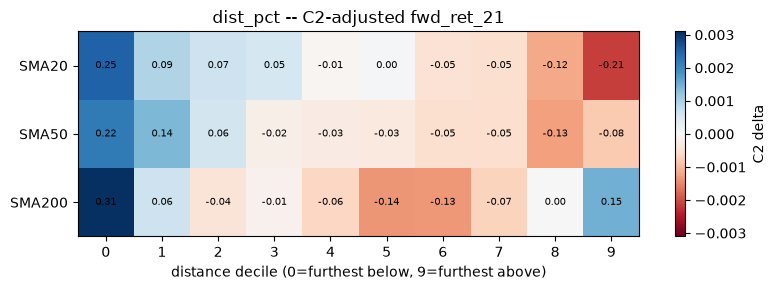

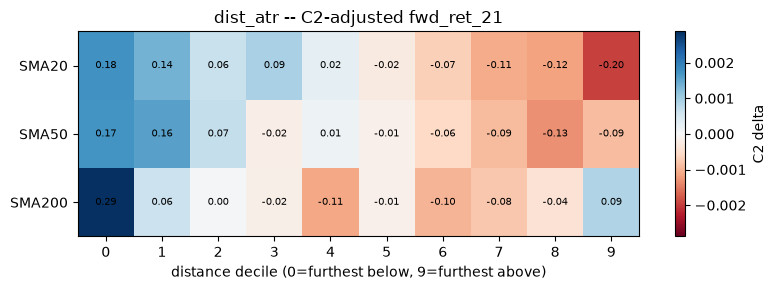

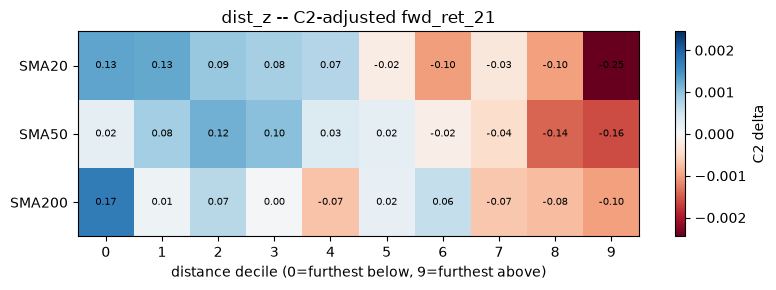

In [4]:
def heatmap_for(feature_prefix, title):
    lookbacks = m04.LOOKBACKS
    grid = np.full((len(lookbacks), m04.N_DECILES), np.nan)
    for i, lb in enumerate(lookbacks):
        table = results[f"{feature_prefix}_sma_{lb}"]
        for _, row in table.iterrows():
            grid[i, int(row["decile"])] = row["c2"]

    fig, ax = plt.subplots(figsize=(8, 3))
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(grid, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(m04.N_DECILES))
    ax.set_xticklabels(range(m04.N_DECILES))
    ax.set_yticks(range(len(lookbacks)))
    ax.set_yticklabels([f"SMA{lb}" for lb in lookbacks])
    ax.set_xlabel("distance decile (0=furthest below, 9=furthest above)")
    ax.set_title(f"{title} -- C2-adjusted fwd_ret_21")
    for i in range(len(lookbacks)):
        for j in range(m04.N_DECILES):
            ax.text(j, i, f"{grid[i,j]*100:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="C2 delta")
    plt.tight_layout()
    plt.show()

heatmap_for("dist_pct", "dist_pct")
heatmap_for("dist_atr", "dist_atr")
heatmap_for("dist_z", "dist_z")


## Shape reading (point estimates only, pre-inference)

- **SMA20 and SMA50, all three normalisations:** broadly monotonic decline from decile 0
  (furthest below) to decile 8/9 (furthest above) — mean-reversion-shaped. Not perfectly
  monotonic at the very top decile in several facets (a small reversal at decile 9).
- **SMA200, `dist_pct` and `dist_atr`:** a genuine U-shape — both ends positive, minimum
  interior. Qualitatively different from 20/50-day, consistent with DESIGN §2.3's
  horizon-dependent momentum-vs-reversion story.
- **SMA200, `dist_z`:** the noisiest facet — no clean pattern. Investigated below.

On shape alone, 8 of 9 facets look like they'd survive the kill criterion. **This is not
the final word** — shape without inference can't distinguish "a real pattern" from "point
estimates that wobble around zero with a slight, meaningless drift." The next section is
what actually answers that.

## Inference: block-bootstrap CI on the C2 decile spread (DESIGN §6.2/§6.3)

`stats/inference.py::block_bootstrap_spread` -- dates resampled in contiguous blocks of
42 (2x the 21-day horizon, per §6.2), 500 draws, 90% CI. Effective N is reported as
distinct dates (§6.3), not the raw row count -- every one of the 90 decile cells has
100,000+ rows, but that vastly overstates independent information given 21-day overlap.

In [5]:
prepared = m04.prepare(panel)

inference_rows = []
for feature in m04.DISTANCE_FEATURES:
    for lookback in m04.LOOKBACKS:
        col = f"{feature}_sma_{lookback}"
        working = prepared.dropna(subset=[col, "fwd_ret_21"]).copy()
        working["decile"] = cross_sectional_bucket(working, col, n_buckets=10)
        working = working.dropna(subset=["decile"])
        working["decile"] = working["decile"].astype(int)

        boot = block_bootstrap_spread(
            working, decile_col="decile", decile_low=0, decile_high=9,
            value_col="fwd_ret_21", match_cols=list(m04.C2_MATCH_COLS),
            date_col="date", block_length=42, n_boot=500, ci=0.90, seed=0,
        )
        boot["feature"] = col
        boot["ci_excludes_zero"] = (boot["ci_low"] > 0) or (boot["ci_high"] < 0)
        inference_rows.append(boot)

inference_df = pd.DataFrame(inference_rows).set_index("feature")[
    ["point_estimate", "ci_low", "ci_high", "n_dates", "n_boot", "ci_excludes_zero"]
]
inference_df


,point_estimate,ci_low,ci_high,n_dates,n_boot,ci_excludes_zero
feature,,,,,,
dist_pct_sma_20,-0.004639,-0.007758,-0.001366,2747,500,True
dist_pct_sma_50,-0.003000,-0.006533,0.000326,2747,500,False
dist_pct_sma_200,-0.001602,-0.005312,0.002444,2747,500,False
dist_atr_sma_20,-0.003716,-0.006649,-0.000937,2747,500,True
dist_atr_sma_50,-0.002601,-0.005791,0.000358,2747,500,False
dist_atr_sma_200,-0.002003,-0.005186,0.001376,2747,500,False
dist_z_sma_20,-0.003736,-0.006543,-0.001182,2729,500,True
dist_z_sma_50,-0.001810,-0.004507,0.001045,2699,500,False
dist_z_sma_200,-0.002724,-0.005497,0.000150,2549,500,False


**This changes the picture substantially.** Only the three **SMA20** facets have a
90% CI that excludes zero (`ci_excludes_zero=True` above). SMA50 and SMA200 -- all six
remaining facets, including the SMA200 U-shapes that looked clean on point estimates
alone -- have a CI straddling zero. Once the data's actual overlap-adjusted uncertainty
is accounted for, the "8 of 9 facets show a pattern" read from the shape-only pass does
not hold. Only SMA20 clears this bar.

**Plateau check, revised:** SMA20 and SMA50 no longer plateau-agree in the way the
point-estimate read suggested -- SMA20 is CI-distinguishable from noise, SMA50 (its
immediate grid neighbour) is not, at any normalisation. That's a genuine break in the
plateau, not a confirmation of one. Worth flagging by name, per CLAUDE.md's plateau
check: *this is exactly the "lone bright pixel" pattern the plateau rule exists to
catch* -- except here it's a lone bright *row* (SMA20 alone), not a single cell, which
is a bit more reassuring (internally consistent across all 3 normalisations) but still
isolated from its nearest lookback neighbour.

## Cost annotation (CLAUDE.md invariant #8)

Only the three SMA20 facets are worth costing -- the other six are already
statistically indistinguishable from zero gross, before any cost is subtracted.
"signals_per_year" = annualised entries into the target decile per ticker, computed
directly from the actual decile-membership transitions (not assumed).

In [6]:
ANNUALIZATION = 252 / 21  # ~12 non-overlapping 21d periods/year, no compounding
U1_SLIPPAGE_BPS = 5  # DESIGN §6.10's U1 tier -- this universe is S&P 500, squarely U1

turnover_rows = []
for feature in m04.DISTANCE_FEATURES:
    col = f"{feature}_sma_20"
    working = prepared.dropna(subset=[col, "fwd_ret_21"]).copy()
    working["decile"] = cross_sectional_bucket(working, col, n_buckets=10)
    working = working.dropna(subset=["decile"]).sort_values(["ticker", "date"])
    working["decile"] = working["decile"].astype(int)
    n_years = (working["date"].max() - working["date"].min()).days / 365.25

    working["in_d9"] = working["decile"] == 9
    prior = working.groupby("ticker")["in_d9"].shift(1)
    entries = working["in_d9"] & (~prior.fillna(False))
    entries_per_ticker_year = entries.sum() / (working["ticker"].nunique() * n_years)
    turnover_rows.append({"feature": col, "entries_per_ticker_year": entries_per_ticker_year})

turnover_df = pd.DataFrame(turnover_rows).set_index("feature")
turnover_df


,entries_per_ticker_year
feature,
dist_pct_sma_20,25.318579
dist_atr_sma_20,25.318579
dist_z_sma_20,25.310513


In [7]:
cost_rows = []
for feature in m04.DISTANCE_FEATURES:
    col = f"{feature}_sma_20"
    boot = inference_df.loc[col]
    entries = turnover_df.loc[col, "entries_per_ticker_year"]

    # decile9 - decile0 is negative -> the tradeable direction is long decile0 / short
    # decile9; report the positive-facing annualised edge.
    gross_low = -boot["ci_high"] * ANNUALIZATION
    gross_point = -boot["point_estimate"] * ANNUALIZATION
    gross_high = -boot["ci_low"] * ANNUALIZATION

    # Two interpretations of DESIGN's "5bps" U1 tier, both reported rather than picking
    # one silently: (a) 5bps already represents a full round-trip's friction per signal;
    # (b) 5bps is one-way, so a round trip costs 10bps. Both legs (long + short) churn
    # independently at `entries` per ticker-year.
    cost_a = 2 * entries * (U1_SLIPPAGE_BPS / 10000)
    cost_b = 2 * entries * (2 * U1_SLIPPAGE_BPS / 10000)

    cost_rows.append({
        "feature": col,
        "gross_annualized_ci_low": gross_low,
        "gross_annualized_point": gross_point,
        "gross_annualized_ci_high": gross_high,
        "cost_annualized_5bps_as_roundtrip": cost_a,
        "cost_annualized_5bps_oneway": cost_b,
        "net_point_optimistic_cost": gross_point - cost_a,
        "net_ci_low_optimistic_cost": gross_low - cost_a,
        "net_point_conservative_cost": gross_point - cost_b,
        "net_ci_low_conservative_cost": gross_low - cost_b,
    })

cost_df = pd.DataFrame(cost_rows).set_index("feature")
cost_df.T


feature,dist_pct_sma_20,dist_atr_sma_20,dist_z_sma_20
gross_annualized_ci_low,0.016395,0.011247,0.014188
gross_annualized_point,0.055671,0.044596,0.044837
gross_annualized_ci_high,0.093097,0.079786,0.078520
cost_annualized_5bps_as_roundtrip,0.025319,0.025319,0.025311
cost_annualized_5bps_oneway,0.050637,0.050637,0.050621
net_point_optimistic_cost,0.030352,0.019277,0.019526
net_ci_low_optimistic_cost,-0.008924,-0.014071,-0.011122
net_point_conservative_cost,0.005034,-0.006042,-0.005784
net_ci_low_conservative_cost,-0.034242,-0.039390,-0.036433


**Reading the cost table:** ~25 entries/ticker/year per leg -> ~50 round trips/year
combined for the long/short pair -- almost exactly DESIGN §6.10's own illustrative
example ("~50 round trips/year at 10bps each carries a 5%/yr hurdle"), and the
conservative-cost annualised hurdle here (`cost_annualized_5bps_oneway`) comes out to
almost exactly that 5%/yr.

- Under the **optimistic** cost assumption, the *point estimate* nets positive for all
  three SMA20 facets -- but the **CI's lower bound nets negative for all three**.
- Under the **conservative** (DESIGN's own illustrative) cost assumption, even the point
  estimate is barely positive for `dist_pct` and net *negative* for `dist_atr`/`dist_z`.

**Conclusion: the SMA20 edge does not robustly survive realistic costs.** Only under a
generous cost assumption does the point estimate clear the bar, and even then the
confidence interval does not. This is exactly DESIGN §6.10's own prior: "most
short-lookback findings will die here, and they should die visibly."


## Diagnostic: the `dist_z_sma_200` null -- normalization-window artifact, or a
genuinely different signal?

Three checks, not just eyeballing: (1) does the 252-day self-normalisation actually
reduce the raw distance's autocorrelation less at 200 days than at 20/50 (i.e. does it
"fail to whiten"), (2) how stable is the z-score's own denominator (rolling-252d std of
`dist_pct`) at each lookback, (3) does `dist_z`'s cross-sectional ranking of stocks
actually diverge from `dist_pct`'s at 200 days, or is it just a noisier copy of the same
ranking.

In [8]:
# (1) Autocorrelation: does z reduce persistence less, in relative terms, at 200d?
print("=== Lag-21 autocorrelation: dist_pct vs dist_z, and the whitening ratio ===")
acf_rows = []
for lb in [20, 50, 200]:
    pct_col, z_col = f"dist_pct_sma_{lb}", f"dist_z_sma_{lb}"
    pct_acfs, z_acfs = [], []
    for ticker, g in panel.groupby("ticker"):
        g = g.sort_values("date")
        pct, z = g[pct_col].dropna(), g[z_col].dropna()
        if len(pct) > 50:
            pct_acfs.append(pct.autocorr(lag=21))
        if len(z) > 50:
            z_acfs.append(z.autocorr(lag=21))
    acf_rows.append({
        "lookback": lb, "dist_pct_acf21": np.nanmean(pct_acfs), "dist_z_acf21": np.nanmean(z_acfs),
        "whitening_ratio_z_over_pct": np.nanmean(z_acfs) / np.nanmean(pct_acfs),
    })
acf_df = pd.DataFrame(acf_rows).set_index("lookback")
acf_df


=== Lag-21 autocorrelation: dist_pct vs dist_z, and the whitening ratio ===


,dist_pct_acf21,dist_z_acf21,whitening_ratio_z_over_pct
lookback,,,
20,-0.075497,-0.072036,0.954148
50,0.322092,0.301613,0.936420
200,0.776864,0.685630,0.882561


In [9]:
# (2) Stability of the z-score's own denominator
print("=== Coefficient of variation of the rolling-252d std of dist_pct (the z denominator) ===")
cv_rows = []
for lb in [20, 50, 200]:
    pct_col = f"dist_pct_sma_{lb}"
    cvs = []
    for ticker, g in panel.groupby("ticker"):
        g = g.sort_values("date")
        rolling_std = g[pct_col].rolling(252).std().dropna()
        if len(rolling_std) > 50 and rolling_std.mean() > 0:
            cvs.append(rolling_std.std() / rolling_std.mean())
    cv_rows.append({"lookback": lb, "mean_cv_of_rolling_std": np.nanmean(cvs)})
cv_df = pd.DataFrame(cv_rows).set_index("lookback")
cv_df


=== Coefficient of variation of the rolling-252d std of dist_pct (the z denominator) ===


,mean_cv_of_rolling_std
lookback,
20,0.332234
50,0.356627
200,0.421693


In [10]:
# (3) Cross-sectional ranking: does dist_z actually reorder stocks vs dist_pct at 200d?
print("=== Cross-sectional Spearman corr(dist_z, dist_pct), averaged over 200 sampled dates ===")
rank_rows = []
for lb in [20, 50, 200]:
    pct_col, z_col = f"dist_pct_sma_{lb}", f"dist_z_sma_{lb}"
    sample_dates = panel["date"].drop_duplicates().sample(200, random_state=0)
    corrs = []
    for d in sample_dates:
        day = panel.loc[panel["date"] == d, [pct_col, z_col]].dropna()
        if len(day) > 30:
            corrs.append(day[pct_col].corr(day[z_col], method="spearman"))
    rank_rows.append({"lookback": lb, "mean_spearman_corr": np.nanmean(corrs)})
rank_df = pd.DataFrame(rank_rows).set_index("lookback")
rank_df


=== Cross-sectional Spearman corr(dist_z, dist_pct), averaged over 200 sampled dates ===


,mean_spearman_corr
lookback,
20,0.927951
50,0.880348
200,0.685952


### Visual: same ticker, `dist_pct_sma_200` vs `dist_z_sma_200` over time

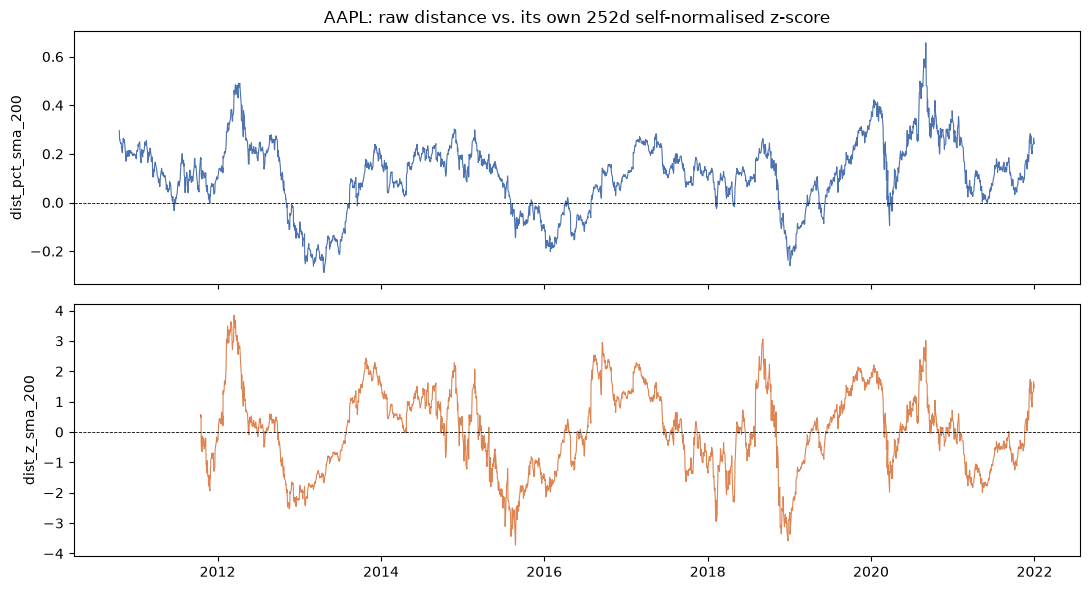

In [11]:
sample_ticker = "AAPL" if (panel["ticker"] == "AAPL").any() else panel["ticker"].iloc[0]
g = panel[panel["ticker"] == sample_ticker].sort_values("date")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(g["date"], g["dist_pct_sma_200"], lw=0.8, color="#4C72B0")
axes[0].axhline(0, color="black", lw=0.6, ls="--")
axes[0].set_ylabel("dist_pct_sma_200")
axes[0].set_title(f"{sample_ticker}: raw distance vs. its own 252d self-normalised z-score")

axes[1].plot(g["date"], g["dist_z_sma_200"], lw=0.8, color="#DD8452")
axes[1].axhline(0, color="black", lw=0.6, ls="--")
axes[1].set_ylabel("dist_z_sma_200")
plt.tight_layout()
plt.show()


### Visual: cross-sectional scatter, `dist_pct` vs `dist_z`, SMA20 vs SMA200 (one sampled date)

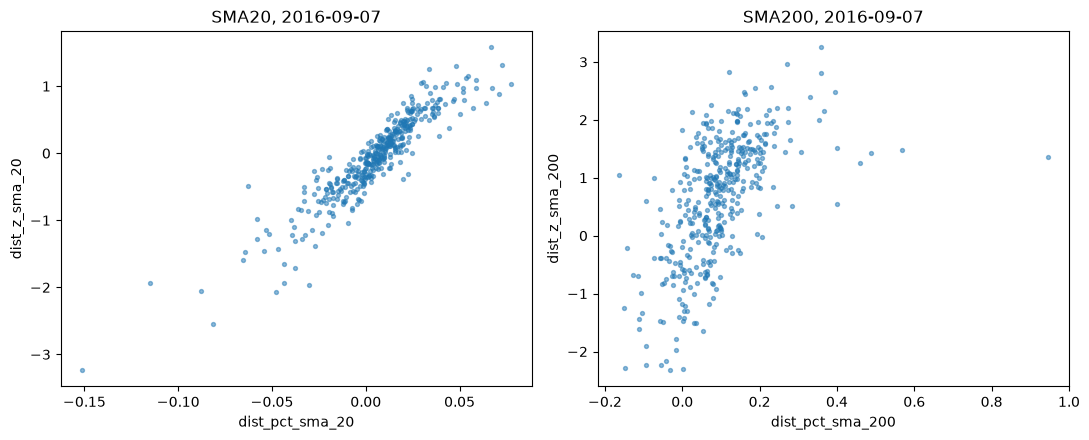

In [12]:
sample_date = panel["date"].drop_duplicates().sample(1, random_state=1).iloc[0]
day = panel[panel["date"] == sample_date]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
for ax, lb in zip(axes, [20, 200]):
    x = day[f"dist_pct_sma_{lb}"]
    y = day[f"dist_z_sma_{lb}"]
    ax.scatter(x, y, s=8, alpha=0.5)
    ax.set_xlabel(f"dist_pct_sma_{lb}")
    ax.set_ylabel(f"dist_z_sma_{lb}")
    ax.set_title(f"SMA{lb}, {sample_date.date()}")
plt.tight_layout()
plt.show()


**Reading the diagnostics:**

- **Autocorrelation:** `dist_z` reduces lag-21 autocorrelation *more*, in relative terms,
  at SMA200 (whitening ratio ~0.88) than at SMA20/50 (~0.93-0.95) — so the normalisation
  isn't literally "doing nothing" at 200 days. But the *absolute* remaining
  autocorrelation at SMA200 is far higher (~0.69) than at SMA20 (~-0.07) or SMA50
  (~0.30) — `dist_z_sma_200` is still a slow-moving series in absolute terms, because
  the thing being normalised (a 200-day MA's distance) has a much longer intrinsic
  memory than a 252-day window can fully detrend.
- **Denominator stability:** the coefficient of variation of the z-score's own rolling
  std rises with lookback (SMA20: 0.33 -> SMA50: 0.36 -> SMA200: 0.42) — the normaliser
  itself is measurably less stable at 200 days, consistent with the hypothesis that a
  252-day window is too close to a 200-day MA's own memory to give a well-behaved
  reference distribution.
- **Cross-sectional ranking:** this is the most decisive one. `dist_z` and `dist_pct`
  rank stocks almost identically at SMA20 (Spearman ~0.93) and SMA50 (~0.88), but
  diverge substantially at SMA200 (~0.69) — `dist_z_sma_200` is not simply a noisier
  copy of `dist_pct_sma_200`'s ranking, it's picking a measurably *different* set of
  stocks as "extended."

**Conclusion:** the evidence points toward **an unstable-normalisation explanation, not
a genuinely-different-signal explanation** — though it doesn't fully separate the two.
The mechanism is coherent: a 252-day self-normalisation window is only ~1.26x the
200-day MA's own lookback (vs. ~12x for SMA20, ~5x for SMA50), so the rolling std used
as the z-score's denominator is itself poorly estimated and regime-dependent at that
horizon, which measurably reshuffles the cross-sectional ranking relative to the raw
distance. Whether that reshuffling is "real information `dist_pct` misses" or "normalisation
noise" can't be fully resolved from these three checks alone, but the *pattern* — rising
denominator instability and falling cross-sectional agreement, both scaling smoothly
with lookback in the same direction — favours an artifact-of-the-mismatched-window
explanation over a "genuinely different signal" one. Practical implication: **avoid
`dist_z` at lookbacks approaching the self-normalisation window's own length (252d)** —
this is a general caution for any future SMA(200)+ work, not specific to M4.

## Tier assignment (DESIGN §9.2)

**Ceiling for this pass, regardless of what the numbers show:** Tier 1 requires holding
across all universe tiers (only S&P 500 tested), being present in the (locked, untouched)
holdout, and surviving BH-FDR correction (not built yet). Tier 2 requires "survives C2
and FDR." **Neither FDR nor holdout nor a second universe tier exists for this slice, so
nothing here can be assigned above Tier 3 — this is a ceiling from missing
infrastructure, not a statement about the effect's strength.**

| Facet | CI excludes 0 (gross) | Survives cost | Tier | Why |
|---|---|---|---|---|
| `dist_pct_sma_20` | Yes | No (CI-low net-negative both cost assumptions) | **Tier 3** | Directionally consistent, plausible mechanism (mean-reversion), but not actionable — fails cost, and FDR/holdout/universe-generality don't exist yet regardless |
| `dist_atr_sma_20` | Yes | No | **Tier 3** | Same reasoning |
| `dist_z_sma_20` | Yes | No | **Tier 3** | Same reasoning |
| `dist_pct_sma_50` | No | — | **Tier 4** | CI straddles zero — tested, no effect beyond C2 control |
| `dist_atr_sma_50` | No | — | **Tier 4** | Same |
| `dist_z_sma_50` | No | — | **Tier 4** | Same |
| `dist_pct_sma_200` | No | — | **Tier 4** | CI straddles zero, despite the clean-looking U-shape on point estimates alone |
| `dist_atr_sma_200` | No | — | **Tier 4** | Same |
| `dist_z_sma_200` | No | — | **Tier 4** | Same, plus the normalisation-instability diagnostic above gives a plausible mechanism for *why* |

**Kill criterion, final verdict:** technically not triggered (SMA20's shape survives
C2-adjusted CI exclusion of zero at all 3 normalisations) — but the surviving evidence is
**far narrower than the shape-only pass suggested (3 of 9 facets, not 8 of 9), and none
of it is actionable once costs are applied.** The honest characterisation of this slice
is: *directionally suggestive at one lookback, rejected everywhere else, and not tradeable
anywhere* — which is itself a real, useful, negative-leaning result, not a "keep looking
for a better cut" invitation.
